Image Stitching and Panorama Creation Objective: Implement a classical image stitching pipeline from scratch + use OpenCV's built-in Stitcher class

Lab: Image Stitching and Panorama Creation

Objective: Build panorama from overlapping photos using classical CV methods.

Tools: Python + OpenCV

Features:

1. Manual step-by-step stitching (ORB + Homography + Simple Blending)
2. OpenCV Stitcher class (PANORAMA & SCANS models)
3. Exposure compensation & multi-band blending (advanced)
4. Visualisation & comparison

Requirements: pip install opencv-python opencv-contrib-python numpy matplotlib

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Tuple
import os
from pathlib import Path

In [2]:
# 0. Configuration & Helper Functions
Image_Path = "C:\\Users\\Lenovo\\Downloads\\Images"

def show_images(images: List[np.ndarray], titles: List[str] = None, figsize=(15,6)):
  "Display multiple images side by side"
  n = len(images)
  plt.figure(figsize = figsize)
  for i, img in enumerate(images):
    plt.subplot(1, n, i+1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(titles[i] if titles and i<len(titles) else f"Image{i+1}")
    plt.axis("off")
  plt.tight_layout()
  plt.show()

In [12]:
#1. Manual Stitching Pipeline
def detect_and_match_features(img1:np.ndarray, img2:np.ndarray):
  """Detect ORB features and match between two images"""
  # Convert to grayscale for feature detection which is alway done on gray images due to computational advantages
  gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY) 
  gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

  #Initialize ORB detector, nfeature parameter tells to find Best 2000 keypoints
  orb = cv2.ORB_create(nfeatures=2000) 

  """Kp1 (Keypoints) are the specific coordinates (x,y) of the features found.
  des1 (Descriptors) are numerical vectors for those keypoints representing what 
  area around the keypoint looks like."""
  kp1, des1 = orb.detectAndCompute(gray1, None)
  kp2, des2 = orb.detectAndCompute(gray2, None)

  #BFMatcher + ratio test
  """BRUTE-force Matcher 
  Norm Hamming is used for binary descriptors like ORB.
  crossCheck=False allows for multiple matches, which is needed for the ratio test."""
  bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=False)

  # This finds the 2 best matches in image2 for every descriptor in image1 
  matches = bf.knnMatch(des1, des2, k=2)

  good_matches = []
  for m,n in matches:
    if m.distance < 0.75*n.distance: #Lowe's ratio test to filter out ambiguous matches
      good_matches.append(m)

  return kp1, des1, kp2, des2, good_matches

In [ ]:
def compute_homography(kp1, kp2, good_matches, min_matches=10):
  """Estimate homography using RANSAC"""
  if len(good_matches) < min_matches: #Run a safety check
    return None, None

  """m.queryIdx: gives the index of keypoint
  .pt: Extracts the (x,y) coordinate
  reshape(-1,1,2) is needed for findHomography input format"""
  src_pts = np.float32([kp1[m.queryIdx].pt for m in good_matches]).reshape(-1,1,2)
  dst_pts = np.float32([kp2[m.trainIdx].pt for m in good_matches]).reshape(-1,1,2)

  """H: The 3x3 homography matrix that maps points from img1 to img2
  mask: A binary mask indicating which matches are inliers (1) and outliers (0)
  RANSAC is used to robustly estimate the homography while ignoring outliers.
  The 5.0 parameter is the RANSAC reprojection threshold, which determines how close points must be to be considered inliers."""
  H, mask=cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)
  return H, mask

In [13]:
def stitch_two_images(img1:np.ndarray, img2:np.ndarray, H:np.ndarray):
  """Warp img2 to img1 coordinate frame + simple blending
  h1,w1: gets height and width of img1, h2,w2 for img2"""
  h1, w1 = img1.shape[:2]
  h2, w2 = img2.shape[:2]

  """Compute output size
  corners: defines the corners of img2 in its own coordinate frame"""
  corners = np.float32([[0,0],[0,h2],[w2,h2],[w2,0]]).reshape(-1,1,2)
  #Warped_corners calculates where the four corners of ing2 land after transformation.
  warped_corners = cv2.perspectiveTransform(corners, H)

  #all_corners is used to combine corners of img1 and transformed corners of img2 to find the bounding box of the final stitched image.
  all_corners = np.concatenate((np.float32([[0,0],[0,h1],[w1,h1],[w1,0]]).reshape(-1,1,2), warped_corners), axis=0)

  """Find minimum and maximum x and y coordinates to determine the size of the output canvas.
  The -0.5 and +0.5 are added to ensure that we have a small margin around the corners to avoid cutting off any part of the images."""
  [xmin, ymin] = np.int32(all_corners.min(axis=0).ravel()-0.5)
  [xmax, ymax] = np.int32(all_corners.max(axis=0).ravel()+0.5)
  
  #Translation matrix to shift the warped image so that all coordinates are positive
  t = np.array([[1,0,-xmin],[0,1,-ymin],[0,0,1]],dtype=np.float32)

  #Warp img2
  result=cv2.warpPerspective(img2, t.dot(H), (xmax-xmin, ymax-ymin))

  #Place img1
  result[-ymin:h1-ymin, -xmin:w1-xmin]=img1

  return result

In [14]:
def simple_stitch_all(images: List[np.ndarray]):
    """Sequentially stitch list of images"""
    panorama = images[0].copy() #Initialize the process. img1 becomes the anchor.
    
    for i in range(1, len(images)): #Starts the loop from the second image, since the first one is already in panorama 
        print(f"Stitching image {i} to panorama...")
        kp1, des1, kp2, des2, good = detect_and_match_features(panorama, images[i])
        
        if len(good) < 10: #Fail-safe 
            print(f"Not enough matches between {i-1} and {i}")
            continue
        
        H, mask = compute_homography(kp1, kp2, good) #Calculates transformation matrix H needed to warp img2 to img1's coordinate frame
        if H is None:
            print("Homography estimation failed")
            continue
        
        panorama = stitch_two_images(panorama, images[i], H) #Updates panorama with the newly stitched image
    
    return panorama

Loading 5 images from C:\Users\Lenovo\Downloads\Images...


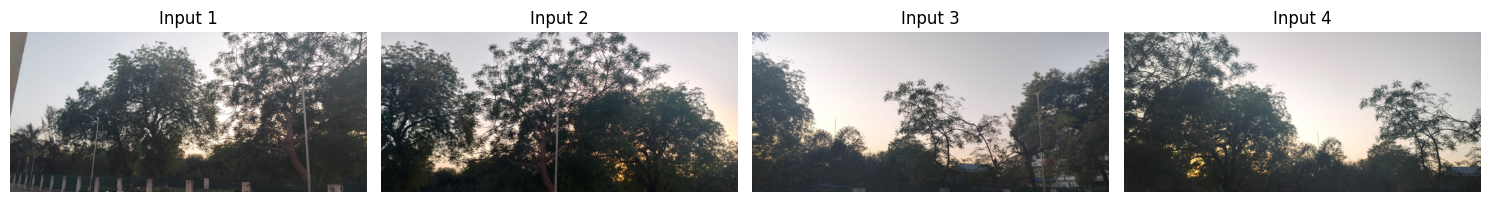


Running manual sequential stitching...
Stitching image 1 to panorama...
Stitching image 2 to panorama...
Not enough matches between 1 and 2
Stitching image 3 to panorama...
Stitching image 4 to panorama...
Not enough matches between 3 and 4


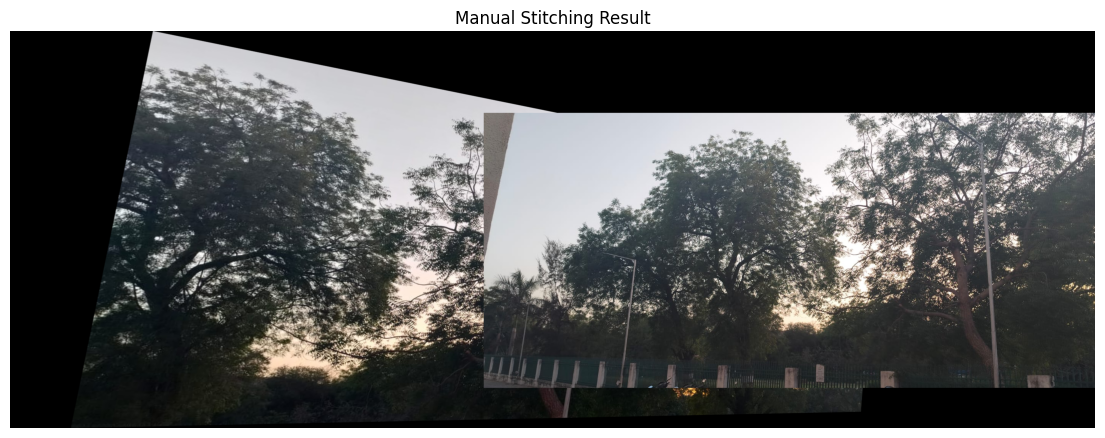

In [8]:
# 2. Load images and run manual stitching

def load_images_from_folder(folder_path: Path) -> List[np.ndarray]:
    """Loads all common image files (jpg, png, etc.) from a given folder."""
    images = []
    if not folder_path.is_dir():
        print(f"Folder not found at {folder_path}. Please ensure the path is correct.")
        return images

    image_extensions = ['*.jpg', '*.jpeg', '*.png', '*.bmp', '*.tiff']
    image_files = []
    for ext in image_extensions:
        image_files.extend(list(folder_path.glob(ext)))
    
    image_files.sort() # Ensure consistent order for sequential stitching

    if not image_files:
        print(f"No image files found in {folder_path}. Please check the folder content.")
        return images

    print(f"Loading {len(image_files)} images from {folder_path}...")
    for img_file in image_files:
        img = cv2.imread(str(img_file))
        if img is not None:
            images.append(img)
        else:
            print(f"Warning: Could not load image {img_file}. Skipping.")
    return images

# IMPORTANT: Before running this cell, please ensure the global variable `Image_Path`
# (defined in cell hALYQSlZO31I) points to a directory containing your actual panorama images.
# Example: Image_Path = Path('/content/my_panorama_images')

# Load images from the specified Image_Path folder
images = load_images_from_folder(Path(Image_Path))

# Limit to the first 5 images as requested, if enough are loaded
if images:
    images = images[:5]

if len(images) < 2:
    print("Warning: Not enough images loaded for stitching. Please ensure Image_Path points to a folder with at least 2 overlapping images.")
    # If you want to stop execution if there aren't enough images, uncomment the line below:
    # raise ValueError("Need at least 2 images to stitch")

# Only display and stitch if images are available
if images:
    show_images(images[:4], titles=[f"Input {i+1}" for i in range(min(4, len(images)))])

    print("\nRunning manual sequential stitching...")
    manual_panorama = simple_stitch_all(images)

    plt.figure(figsize=(14, 8))
    plt.imshow(cv2.cvtColor(manual_panorama, cv2.COLOR_BGR2RGB))
    plt.title("Manual Stitching Result")
    plt.axis('off')
    plt.show()
else:
    print("No images to process for stitching. Please load images into the specified Image_Path.")


Running OpenCV Stitcher (PANORAMA mode)...
Stitching successful!


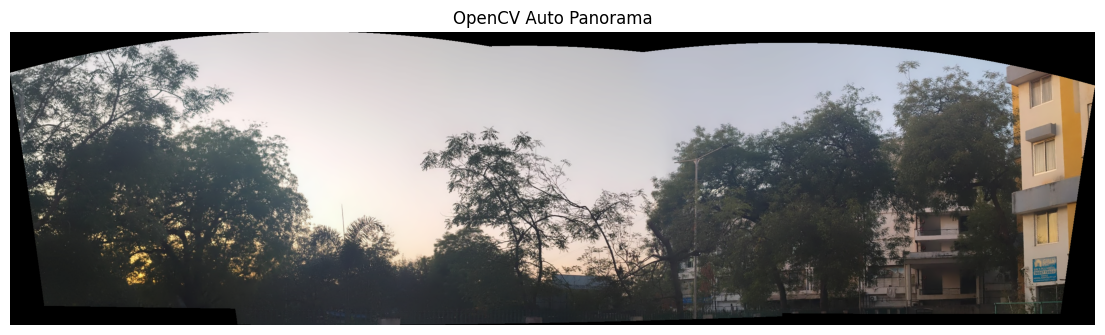

In [15]:
# 3. OpenCV builtin Stitcher 
"""OpenCV Stitcher API - a high level "all-in-one" tool that handles complex math, bundle 
adjustment and blending internally. It has different modes like PANORAMA (for wide scenes) 
and SCANS (for documents)."""

print("\nRunning OpenCV Stitcher (PANORAMA mode)...")

#Initializes the stitcher object in panorama mode.
stitcher = cv2.Stitcher_create(cv2.Stitcher_PANORAMA) 
# Optional tuning
# stitcher.setWaveCorrection(True)
# stitcher.setPanoConfidenceThresh(0.5)

status, pano = stitcher.stitch(images)
"""This line performs all tasks including finding features, matching them, 
estimating transformations, and blending the images together to create a 
panorama."""
if status == cv2.Stitcher_OK: 
    print("Stitching successful!")
    plt.figure(figsize=(14, 8))
    plt.imshow(cv2.cvtColor(pano, cv2.COLOR_BGR2RGB))
    plt.title("OpenCV Auto Panorama")
    plt.axis('off')
    plt.show()
else:
    print("Stitching failed. Status code:", status)
    print("Common reasons: too little overlap, large parallax, exposure differences")



Trying SCANS mode + exposure compensation...


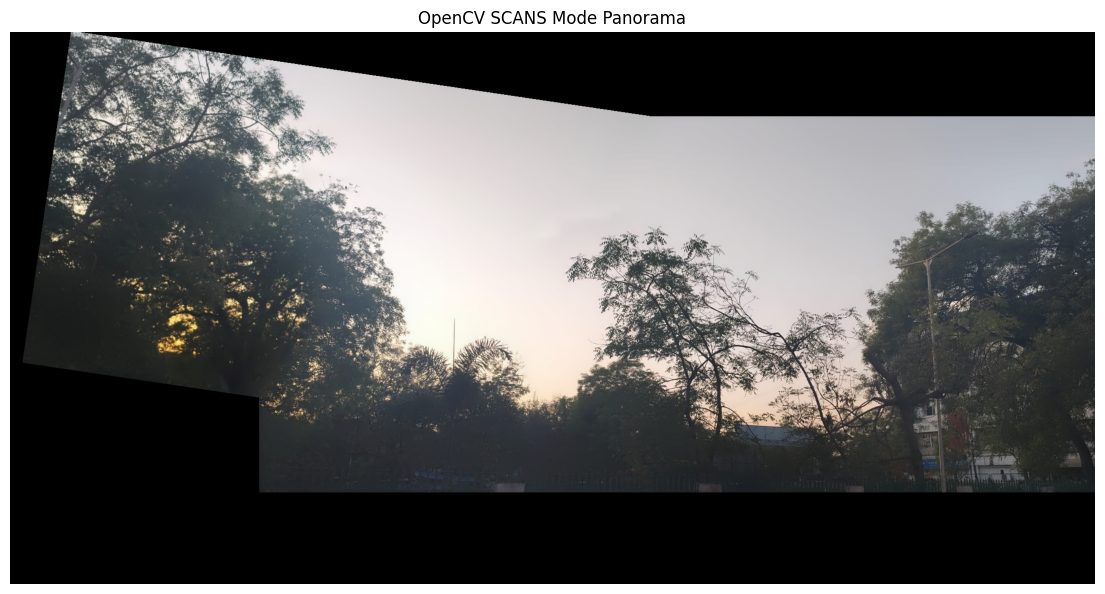

In [16]:
#4. Advanced: SCAN mode or exposure compensation
print("\nTrying SCANS mode + exposure compensation...")

stitcher_scans = cv2.Stitcher_create(cv2.Stitcher_SCANS) #Initializes stitcher object in SCAN mode.
#Triggers the SCAN pipeline which includes feature detection, registeration, adjustments, and blending.
status_scans, pano_scans = stitcher_scans.stitch(images) 
if status_scans == cv2.Stitcher_OK:
    plt.figure(figsize=(14, 8))
    plt.imshow(cv2.cvtColor(pano_scans, cv2.COLOR_BGR2RGB))
    plt.title("OpenCV SCANS Mode Panorama")
    plt.axis('off')
    plt.show()


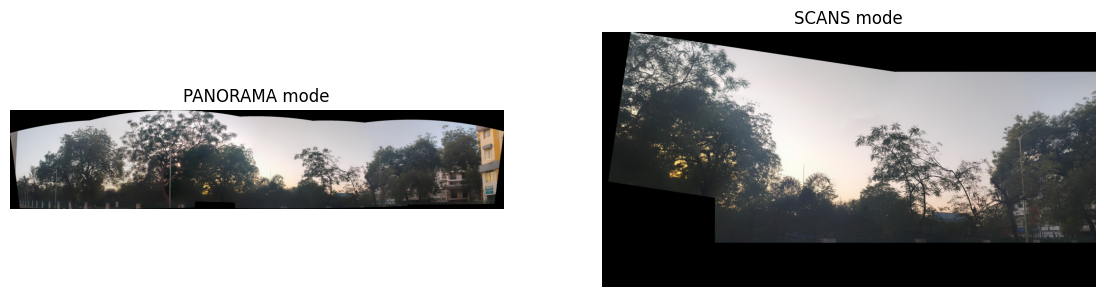

Lab completed!


In [ ]:
# Bonus: Compare side-by-side
if 'pano' in locals() and 'pano_scans' in locals(): #Safety check for both panoramas before displaying
    plt.figure(figsize=(14, 8)) #Setup size of display window.
    plt.subplot(1,2,1) #Creates layout with 1 row, 2 columns, selects the first left slot.
    plt.imshow(cv2.cvtColor(pano, cv2.COLOR_BGR2RGB))
    plt.title("PANORAMA mode") #Label for the first image
    plt.axis('off')
    
    plt.subplot(1,2,2) #Select second slot.
    plt.imshow(cv2.cvtColor(pano_scans, cv2.COLOR_BGR2RGB))
    plt.title("SCANS mode") #Label for the second image
    plt.axis('off') #Hides X & Y coordinates for cleaner display.
    plt.show()

print("Lab completed!") #Hence, prooved!!!
